In [1]:
import numpy as np
import joblib
import json
import os
import torch
from torch.utils.data import DataLoader, TensorDataset
from src.models.VAE import  VAE1D, compute_scores
import pandas as pd
import zipfile

from torch.utils.data import DataLoader, TensorDataset 
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Load test set

In [3]:
from src.utils import find_folder

data_dir = find_folder('.', 'data_processed')
npz_path = os.path.join(data_dir, "data_processed.npz")

data = np.load(npz_path)

X_test_signal_raw   = data["X_test_signal_raw"]
X_test_coeffs_raw   = data["X_test_coeffs_raw"]
y_test              = data["y_test"]

mean_x              = data["mean_x"]
std_x               = data["std_x"]
mean_c              = data["mean_c"]
std_c               = data["std_c"]

normal_class_id     = data["normal_class_id"]

In [4]:
# Normalize with the dev statistics
X_test_signal  = (X_test_signal_raw  - mean_x) / (std_x  + 1e-8)
X_test_coeffs  = (X_test_coeffs_raw  - mean_c) / (std_c  + 1e-8)

In [5]:
test_norm_signal = X_test_signal[y_test == normal_class_id]
test_norm_coeffs = X_test_coeffs[y_test == normal_class_id] 
test_ano_signal  = X_test_signal[y_test != normal_class_id]
test_ano_coeffs  = X_test_coeffs[y_test != normal_class_id]

test_norm_signal_tensor = torch.tensor(test_norm_signal).permute(0, 2, 1)
test_ano_signal_tensor = torch.tensor(test_ano_signal).permute(0, 2, 1)

test_norm_coeffs_tensor = torch.tensor(test_norm_coeffs)
test_ano_coeffs_tensor = torch.tensor(test_ano_coeffs)

### Load Models

In [6]:
in_dir = find_folder('.', 'saved_models_and_params')

# Load best_hps.json
with open(os.path.join(in_dir, "best_hps.json"), "r") as f:
    hps = json.load(f)

beta_value  = hps["beta"]
lr          = hps["lr"]
latent_dim  = int(hps["latent_dim"])
n_blocks    = int(hps["n_blocks"])
batch_size  = int(hps["batch_size"])
epochs      = int(hps["epochs"])


In [7]:
NUM_INPUT_CH = 1
NUM_COEFF_CH = 21

In [8]:
# Load VAE
model = VAE1D(input_ch=NUM_INPUT_CH, coeff_ch=NUM_COEFF_CH, latent_dim=latent_dim, n_blocks=n_blocks)
vae_path = os.path.join(in_dir, "vae_state.pth")
model.load_state_dict(torch.load(vae_path, map_location=device))
model.to(device)
model.eval()

/tmp/ipykernel_10462/3228108897.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(vae_path, map_location=device))


VAE1D(
  (signal_encoder): Sequential(
    (0): Conv1d(1, 32, kernel_size=(19,), stride=(2,), padding=(9,))
    (1): LeakyReLU(negative_slope=0.01)
    (2): ResBlock1D(
      (block): Sequential(
        (0): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): LeakyReLU(negative_slope=0.01)
        (2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
      )
    )
    (3): ResBlock1D(
      (block): Sequential(
        (0): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
        (1): LeakyReLU(negative_slope=0.01)
        (2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      )
    )
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc_mu): Linear(in_features=32789, out_features=64, bias=True)
  (fc_logv): Linear(in_features=32789, out_features=64, bias=True)
  (fc_dec): Linear(in_features=64, out_features=32768, bias=True)
  (decoder): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(3

In [9]:
# Load XGB and threshold
clf       = joblib.load(os.path.join(in_dir, "xgb_clf.joblib"))
best_thresh = json.load(open(os.path.join(in_dir, "threshold.json"), "r"))["best_thresh"]

## `Testing`

In [10]:
# Balance the test set so the metrics are consistent

N_norm = len(test_norm_signal_tensor)
N_ano  = len(test_ano_signal_tensor)
N_test = min(N_norm, N_ano)

norm_signals_test = test_norm_signal_tensor[:N_test]
ano_signals_test  = test_ano_signal_tensor[:N_test]
norm_coeffs_test  = test_norm_coeffs_tensor[:N_test]
ano_coeffs_test   = test_ano_coeffs_tensor[:N_test]

X_test_final_signal = torch.cat([norm_signals_test, ano_signals_test], dim=0)
X_test_final_coeffs = torch.cat([norm_coeffs_test, ano_coeffs_test], dim=0)

y_test_final = torch.tensor(
    np.concatenate([np.zeros(N_test), np.ones(N_test)]),
    dtype=torch.long
)

test_loader_final = DataLoader(TensorDataset(X_test_final_signal, X_test_final_coeffs, y_test_final), batch_size=batch_size)

In [11]:
print("Extracting features from the unseen test set...")
errs_test, zs_test = compute_scores(model, test_loader_final, device, beta=beta_value)
errs_test = np.nan_to_num(errs_test, nan=0.0, posinf=1e6, neginf=-1e6)
zs_test = np.nan_to_num(zs_test, nan=0.0, posinf=1e6, neginf=-1e6)
X_test_clf = np.hstack([errs_test.reshape(-1, 1), zs_test])
y_test_clf = y_test_final.numpy()

Extracting features from the unseen test set...


In [12]:
print("Evaluating classifier on the unseen test set...")
probs = clf.predict_proba(X_test_clf)[:, 1]
y_pred = (probs >= best_thresh).astype(int)

metrics = {
    'roc_auc': roc_auc_score(y_test_clf, probs),
    'precision': precision_score(y_test_clf, y_pred), 
    'recall': recall_score(y_test_clf, y_pred),
    'f1': f1_score(y_test_clf, y_pred),
    'accuracy': accuracy_score(y_test_clf, y_pred)
}

Evaluating classifier on the unseen test set...


## `Results`

In [13]:
from src.utils import display_metrics_as_md
display_metrics_as_md(metrics)

<h2 style='margin-bottom:0.3em'>Final Metrics on Unseen Test Set</h2>
<p style='font-size:16px; margin:0.2em 0'><strong>Roc Auc:</strong> 0.8058</p>
<p style='font-size:16px; margin:0.2em 0'><strong>Precision:</strong> 0.7116</p>
<p style='font-size:16px; margin:0.2em 0'><strong>Recall:</strong> 0.7400</p>
<p style='font-size:16px; margin:0.2em 0'><strong>F1:</strong> 0.7255</p>
<p style='font-size:16px; margin:0.2em 0'><strong>Accuracy:</strong> 0.7200</p>



Confusion matrix:
             Pred Neg  Pred Pos
Actual Neg      4230      1812
Actual Pos      1571      4471


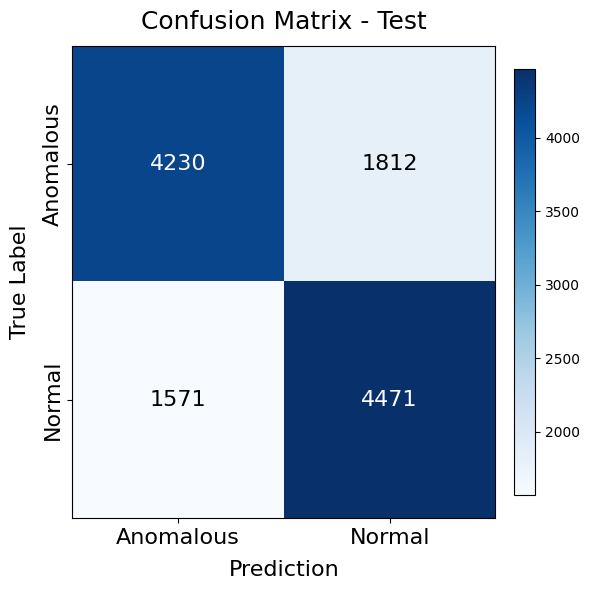

In [14]:
cm_val = confusion_matrix(y_test_clf, y_pred)  

cm_val_df = pd.DataFrame(
    cm_val,
    index=["Actual Neg","Actual Pos"],
    columns=["Pred Neg","Pred Pos"]
)
print("\nConfusion matrix:\n", cm_val_df)

from src.plot_metrics import plot_confusion_matrix

plot_confusion_matrix(cm_val, class_names=["Anomalous", "Normal"], title="Confusion Matrix - Test")

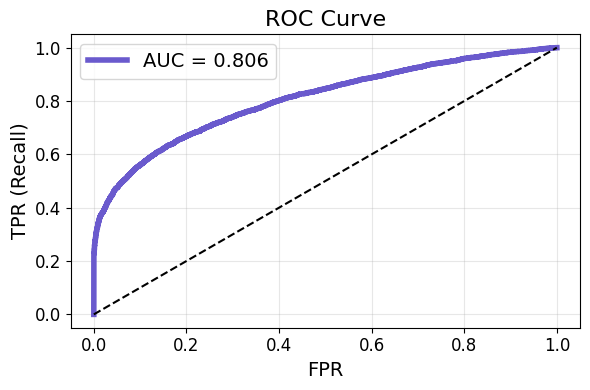

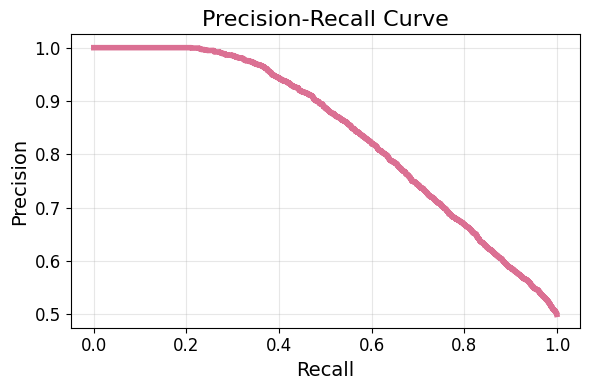

In [15]:
from src.plot_metrics import plot_roc_pr

plot_roc_pr(y_test_clf, probs, lw=4, font_size=14, roc_color='slateblue', pr_color='palevioletred')

### Save Predictions

In [16]:
apellido1 = "Tissera"
apellido2 = "Couriel" 
model_name = "VAE1D"    

df_preds = pd.DataFrame({
    "y_true": y_test_clf,
    "y_pred": y_pred,
    "prob_positive": probs
})

csv_filename = f"{apellido1}_{apellido2}_{model_name}_predictions.csv"
df_preds.to_csv(csv_filename, index=False)
print(f"CSV file saved: {csv_filename}")

CSV file saved: Tissera_Couriel_VAE1D_predictions.csv


In [17]:
# A zip
zip_filename = f"{apellido1}_{apellido2}_Predictions_PF.zip"
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(csv_filename) 
print(f"ZIP file generated: {zip_filename}")

ZIP file generated: Tissera_Couriel_Predictions_PF.zip
